In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors

# 1. Load data
df = pd.read_csv('experimental_data.csv')

# 2. Get all features for each solvent and merge with original data
def get_all_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {}
    return Descriptors.CalcMolDescriptors(mol)

all_features_df = df['SMILES'].apply(get_all_features).apply(pd.Series)

analysis_df = pd.concat([df.drop('SMILES', axis=1), all_features_df], axis=1)

# 3. Clean up empty columns and those that have no variance 
analysis_df = analysis_df.dropna(axis=1, how='all')
analysis_df = analysis_df.loc[:, analysis_df.nunique() > 1]

# 4. Calculate the Pearson Correlation of every feature against Stability_Hours and sort by absolute correlation
correlations = analysis_df.drop('Solvent', axis=1).corr()['Stability_Hours']

top_correlations = correlations.drop('Stability_Hours').sort_values(key=abs, ascending=False)

# 5. Print the results
print("Top 10 Chemical Descriptors Correlated with Stability:")
print("-" * 65)
print(top_correlations.head(10))

Top 10 Chemical Descriptors Correlated with Stability:
-----------------------------------------------------------------
BCUT2D_CHGLO         0.951115
FractionCSP3        -0.932666
BCUT2D_LOGPLOW       0.877724
MaxEStateIndex      -0.870466
MaxAbsEStateIndex   -0.870466
VSA_EState2         -0.870466
BertzCT             -0.843305
HeavyAtomMolWt      -0.839489
BCUT2D_MWLOW         0.834530
Chi1                -0.831114
Name: Stability_Hours, dtype: float64


In [2]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

# 1. Define top 4 descriptors based on previous correlation analysis
top_4_descriptors = [
    'BCUT2D_CHGLO', 
    'FractionCSP3', 
    'BCUT2D_LOGPLOW',
    'MaxAbsEStateIndex',
    'BertzCT',
]

# 2. Load and process data
df = pd.read_csv('experimental_data.csv')

def get_specific_features(smiles, feature_list):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return {f: None for f in feature_list}
    
    all_desc = Descriptors.CalcMolDescriptors(mol)
    return {f: all_desc[f] for f in feature_list}

# 3. Create the feature dataframe
features_df = df['SMILES'].apply(lambda x: get_specific_features(x, top_4_descriptors)).apply(pd.Series)

# 4. Calculate the Inter-Correlation Matrix
corr_matrix = features_df.corr()

# 5. Display the Results
print("Inter-Correlation Matrix (Linearity Check):")
print("-" * 60)
print(corr_matrix.round(4))
print("-" * 60)


Inter-Correlation Matrix (Linearity Check):
------------------------------------------------------------
                   BCUT2D_CHGLO  FractionCSP3  BCUT2D_LOGPLOW  \
BCUT2D_CHGLO             1.0000       -0.9316          0.9402   
FractionCSP3            -0.9316        1.0000         -0.7635   
BCUT2D_LOGPLOW           0.9402       -0.7635          1.0000   
MaxAbsEStateIndex       -0.9254        0.9767         -0.7709   
BertzCT                 -0.9471        0.9406         -0.8188   

                   MaxAbsEStateIndex  BertzCT  
BCUT2D_CHGLO                 -0.9254  -0.9471  
FractionCSP3                  0.9767   0.9406  
BCUT2D_LOGPLOW               -0.7709  -0.8188  
MaxAbsEStateIndex             1.0000   0.9773  
BertzCT                       0.9773   1.0000  
------------------------------------------------------------


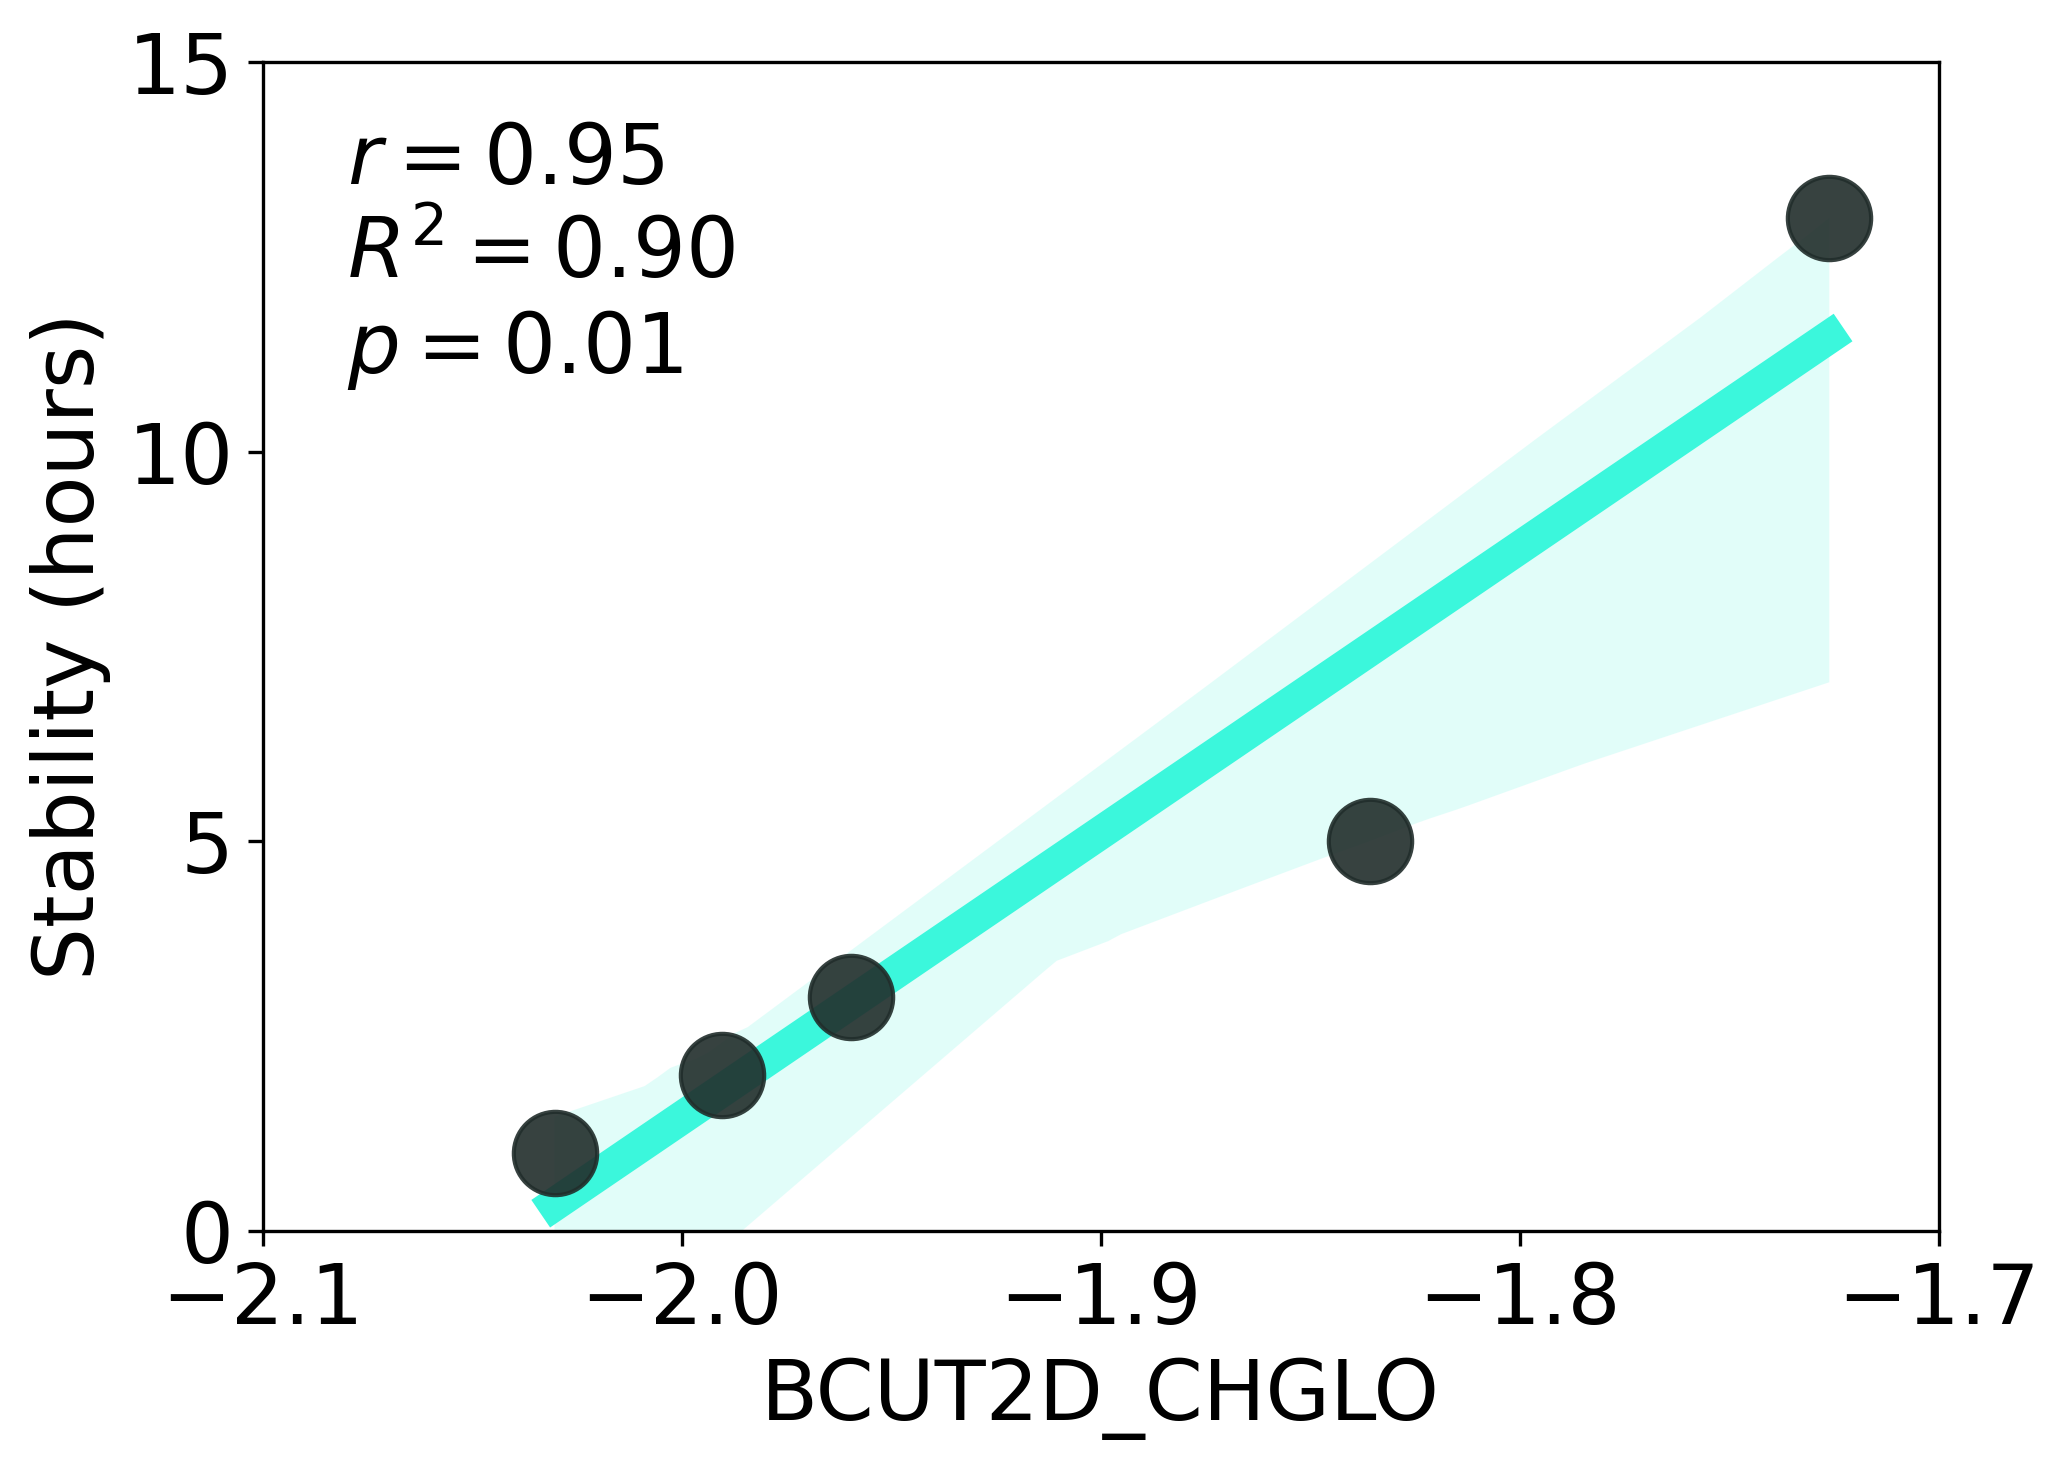

 BCUT2D_CHGLO  Stability_Hours
    -1.726115               13
    -2.030407                1
    -1.990335                2
    -1.959683                3
    -1.835858                5


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Define a function to plot descriptor correlation with Stability_Hours
def plot_descriptor_correlation(df, descriptor_name, target_name):
    
    # 2. Within the function, calculate Pearson correlation and p-value
    mask = df[descriptor_name].notnull() & df[target_name].notnull()
    r, p = stats.pearsonr(df[mask][descriptor_name], df[mask][target_name])
    r_squared = r**2
    
    plt.figure(figsize=(7, 5), dpi=300)
    
    plot = sns.regplot(
        data=df, 
        x=descriptor_name, 
        y=target_name,
        line_kws={'color': '#3BF7DC', 'lw': 8,'zorder': 2},
        scatter_kws={'s': 400, 'color': '#212D2B','alpha': 0.9,'zorder': 3},
        ci=95
    )
    
    plt.xlabel(descriptor_name, fontsize=20)
    plt.xlim(-2.1, -1.7)
    plt.xticks(np.arange(-2.1, -1.7, 0.1), fontsize=20)
    plt.ylabel('Stability (hours)', fontsize=20)
    plt.ylim(0,15)
    plt.yticks(np.arange(0, 16, 5), fontsize=20)
    
    # 3. Add the correlation coefficient and p-value on the plot
    plt.text(
        0.05, 0.95,
        f'$r = {r:.2f}$\n$R^2 = {r_squared:.2f}$\n$p = {p:.2f}$', 
        transform=plt.gca().transAxes, 
        verticalalignment='top',
        fontsize=20
    )
    
    # 4. Print the results
    plt.tight_layout()
    plt.show()
    print(df[mask][[descriptor_name, target_name]].to_string(index=False))

# 5. Execute the plot function using analysis_df and the top descriptor
plot_descriptor_correlation(analysis_df, 'BCUT2D_CHGLO', 'Stability_Hours')

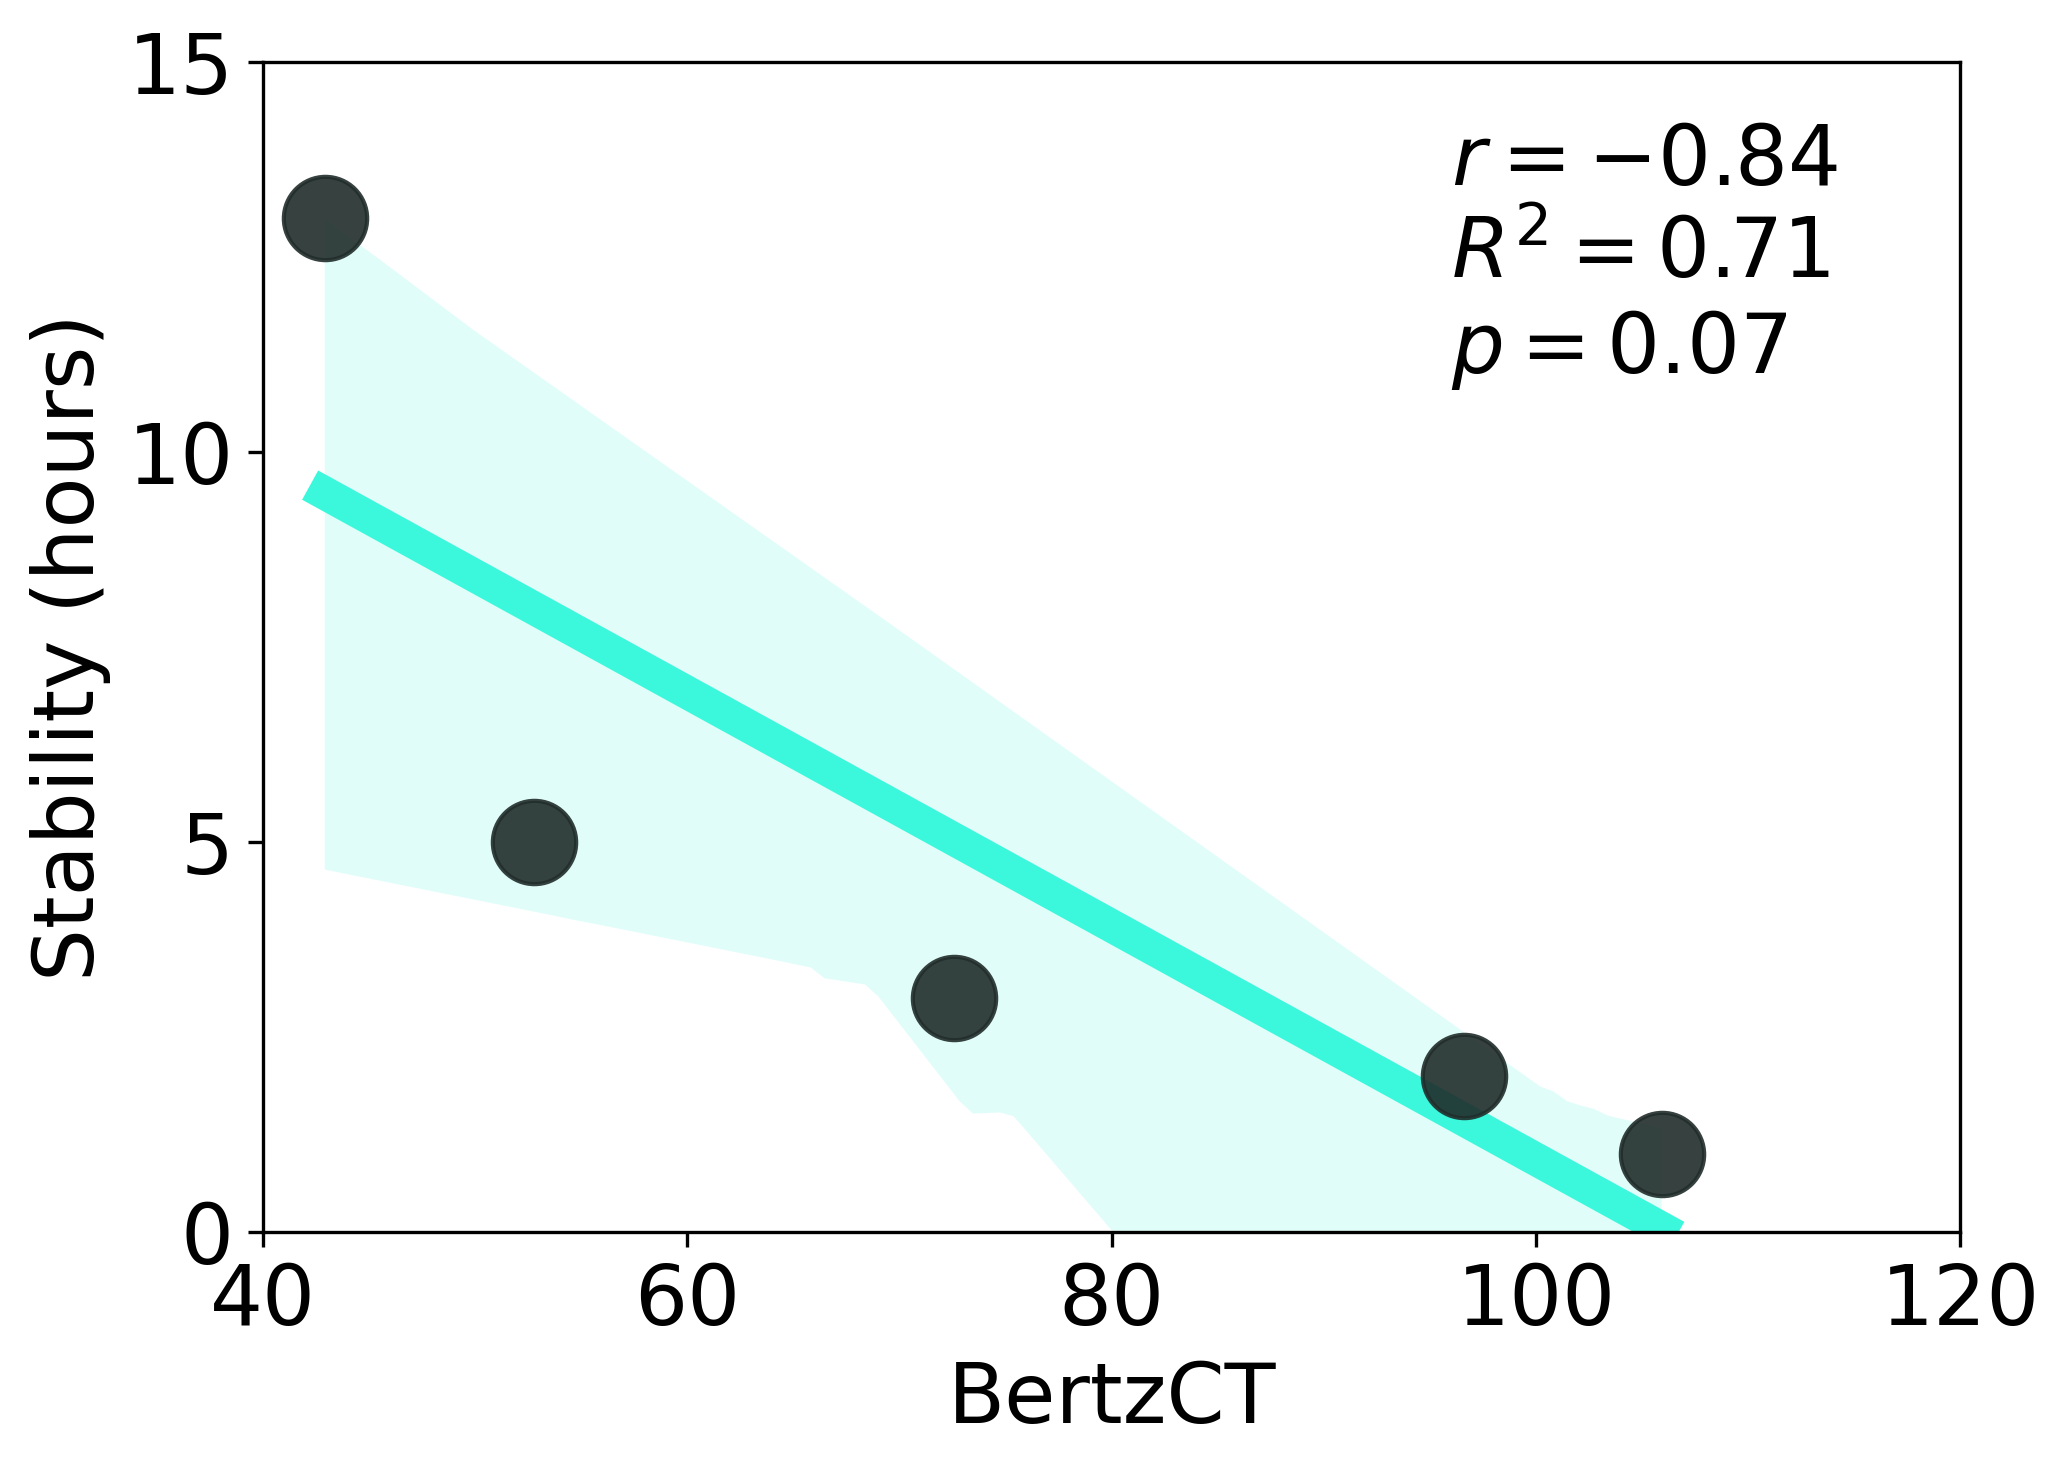

   BertzCT  Stability_Hours
 42.912609               13
105.920939                1
 96.601792                2
 72.580271                3
 52.754888                5


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Define a function to plot descriptor correlation with Stability_Hours
def plot_descriptor_correlation(df, descriptor_name, target_name):
    
    # 2. Within the function, calculate Pearson correlation and p-value
    mask = df[descriptor_name].notnull() & df[target_name].notnull()
    r, p = stats.pearsonr(df[mask][descriptor_name], df[mask][target_name])
    r_squared = r**2
    
    plt.figure(figsize=(7, 5), dpi=300)
    
    plot = sns.regplot(
        data=df, 
        x=descriptor_name, 
        y=target_name,
        line_kws={'color': '#3BF7DC', 'lw': 8,'zorder': 2},
        scatter_kws={'s': 400, 'color': '#212D2B','alpha': 0.9,'zorder': 3},
        ci=95
    )
    
    plt.xlabel(descriptor_name, fontsize=20)
    plt.xticks(np.arange(40,121,20), fontsize=20)
    plt.xlim(40, 120)
    plt.ylabel('Stability (hours)', fontsize=20)
    plt.ylim(0,15)
    plt.yticks(np.arange(0, 16, 5), fontsize=20)
    
    # 3. Add the correlation coefficient and p-value on the plot
    plt.text(
        0.70, 0.95,
        f'$r = {r:.2f}$\n$R^2 = {r_squared:.2f}$\n$p = {p:.2f}$', 
        transform=plt.gca().transAxes, 
        verticalalignment='top',
        fontsize=20
    )
    
    # 4. Print the results
    plt.tight_layout()
    plt.show()
    print(df[mask][[descriptor_name, target_name]].to_string(index=False))

# 5. Execute the plot function using analysis_df and the top descriptor
plot_descriptor_correlation(analysis_df, 'BertzCT', 'Stability_Hours')

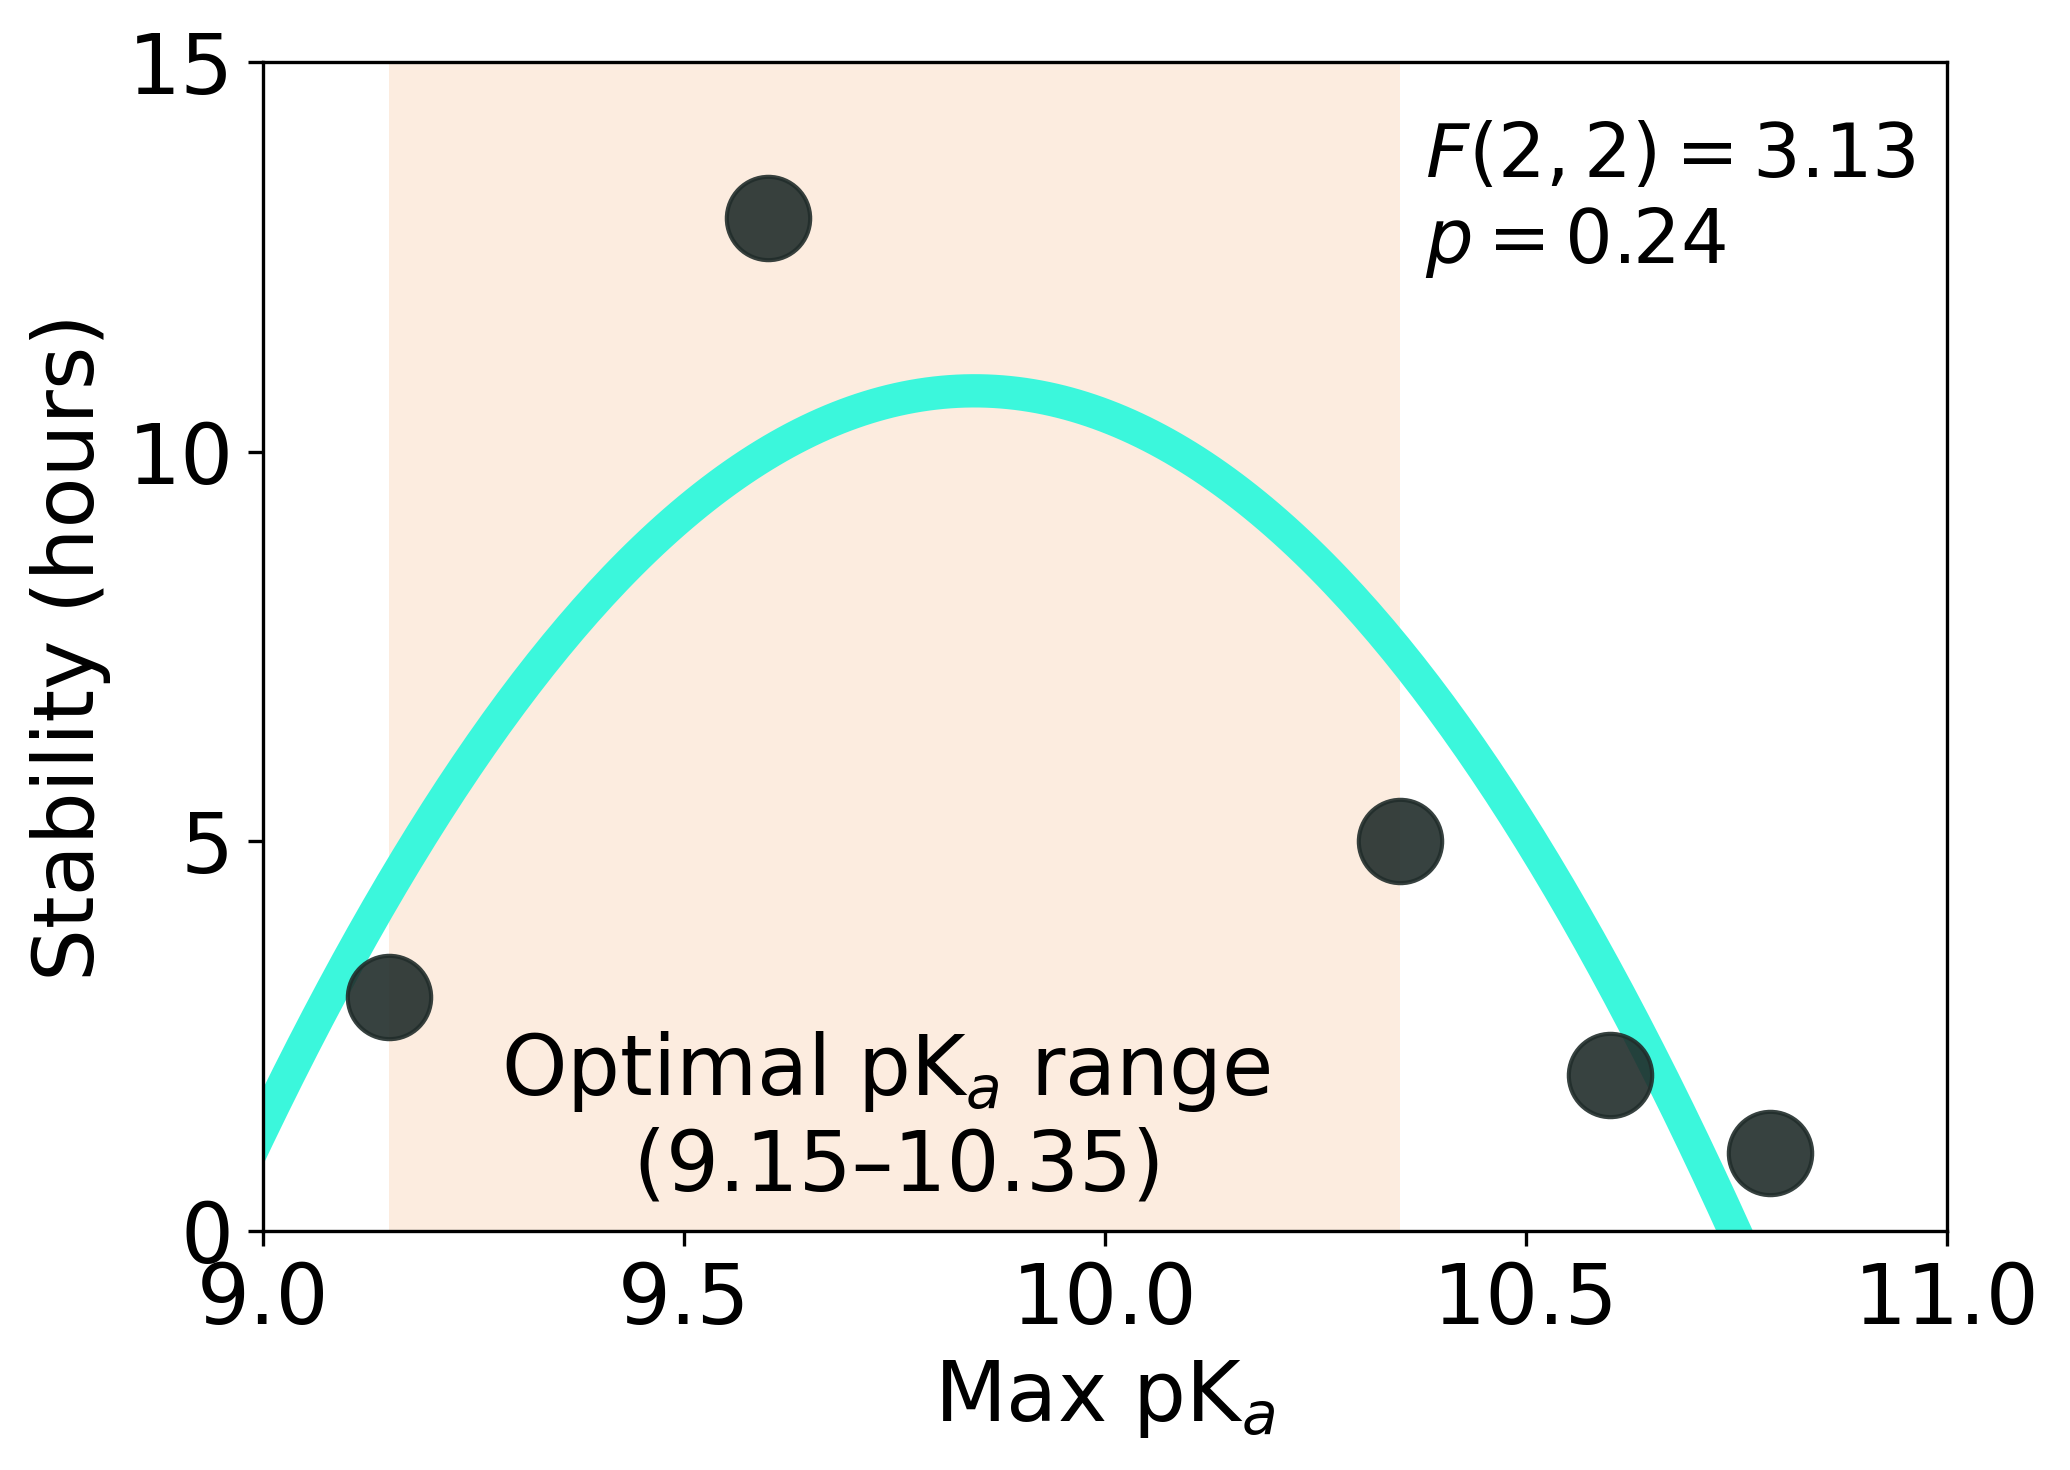

Top 3 Empirical Range: 9.15 to 10.35
F-statistic: 3.1283 (p=0.2422)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import r2_score

# 1. Load data
df = pd.read_csv('experimental_data.csv')
x = df['Max_Amine_pKa'].values
y = df['Stability_Hours'].values

# 2. Perform quadratic fit and calculate stats
coeffs = np.polyfit(x, y, 2)
a, b, c = coeffs
p = np.poly1d(coeffs)

y_pred = p(x)
r2 = r2_score(y, y_pred)

# Calculate stats from statsmodels for dynamic labels
X_stats = sm.add_constant(np.column_stack((x, x**2)))
model = sm.OLS(y, X_stats).fit()

# Extract dynamic stats
f_val = model.fvalue
f_p = model.f_pvalue
df_mod = int(model.df_model)  # Degrees of freedom (Model)
df_res = int(model.df_resid)  # Degrees of freedom (Residual)

# Identify bounds for top 3 stability points
top_3_pka = df.nlargest(3, 'Stability_Hours')['Max_Amine_pKa']
pka_min, pka_max = top_3_pka.min(), top_3_pka.max()

# 3. Graph
plt.figure(figsize=(7, 5), dpi=300)

# Shaded region between top 3 points
plt.axvspan(pka_min, pka_max, facecolor='#F4A261', edgecolor='none', alpha=0.2, zorder=1)

plt.scatter(x, y, color='#212D2B', alpha=0.9, s=400, zorder=3)

# Quadratic fit line with dynamic F-stat label for the legend
x_smooth = np.linspace(x.min() - 0.5, x.max() + 0.5, 300)
plt.plot(x_smooth, p(x_smooth), color='#3BF7DC', linewidth=8, zorder=2)

stats_text = (f'$F({df_mod}, {df_res}) = {f_val:.2f}$\n'
              f'$p = {f_p:.2f}$')
plt.gca().text(0.69, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=18, verticalalignment='top')

plt.gca().text(0.37, 0.02, 'Optimal pK$_a$ range\n (9.15–10.35)', transform=plt.gca().transAxes, fontsize=20, verticalalignment='bottom', horizontalalignment='center')

# Standard labeling and formatting
plt.xlabel(r'Max pK$_a$', fontsize=20)
plt.xticks(np.arange(9, 11.1, 0.5), fontsize=20)
plt.xlim(9, 11)
plt.ylabel('Stability (hours)', fontsize=20)
plt.ylim(0, 15)
plt.yticks(np.arange(0, 16, 5), fontsize=20)

plt.tight_layout()
plt.show()

print(f"Top 3 Empirical Range: {pka_min} to {pka_max}")
print(f"F-statistic: {f_val:.4f} (p={f_p:.4f})")